The main objective of this study is to demonstrate the effect of different degrees of multicollinearity among predictors on their regression coefficients and corresponding standard error estimates, as well as the potential effect on p-values, under different scenarios of multicollinearity among predictors using the generated simulated dataset. Since multicollinearity in regression may involve more than two independent variables, in this simulation study we consider different pairwise Pearson correlation coefficients for five independent variables.



The first fictitious dataset

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Set seed for reproducibility
np.random.seed(42)

# Define mean vector (y, x1, x2, x3 x4)
mu = np.array([100.76, 8.98, 15.7, 45.14, 6.39])

# Define standard deviations 
sigma = np.array([3.32, 2.73, 5.35, 10.42,0.23 ])

# Define correlation matrix (example)
rho_matrix = np.array([
    [1.0, 0.6, 0.3, 0.4, 0.35],  # Correlations with y
    [0.6, 1.0, 0.25, 0.75, 0.15],  # Correlations with x1
    [0.3, 0.25, 1.0, 0.6, 0.65],   # Correlations with x2
    [0.4, 0.75, 0.6, 1.0, 0.3],    # Correlations with x3
    [0.35, 0.15, 0.65, 0.3, 1.0]    # Correlations with x4
])

# Calculate the covariance matrix using: cov(x1, x2) = rho * sigma_x1 * sigma_x2
cov_matrix = np.outer(sigma, sigma) * rho_matrix

# Generate data (800 samples) from the four-dimensional multivariate normal distribution
n_samples = 2000
data = np.random.multivariate_normal(mu, cov_matrix, size=n_samples)

# Convert to DataFrame for easier handling
df = pd.DataFrame(data, columns=['y', 'x1', 'x2', 'x3','x4'])

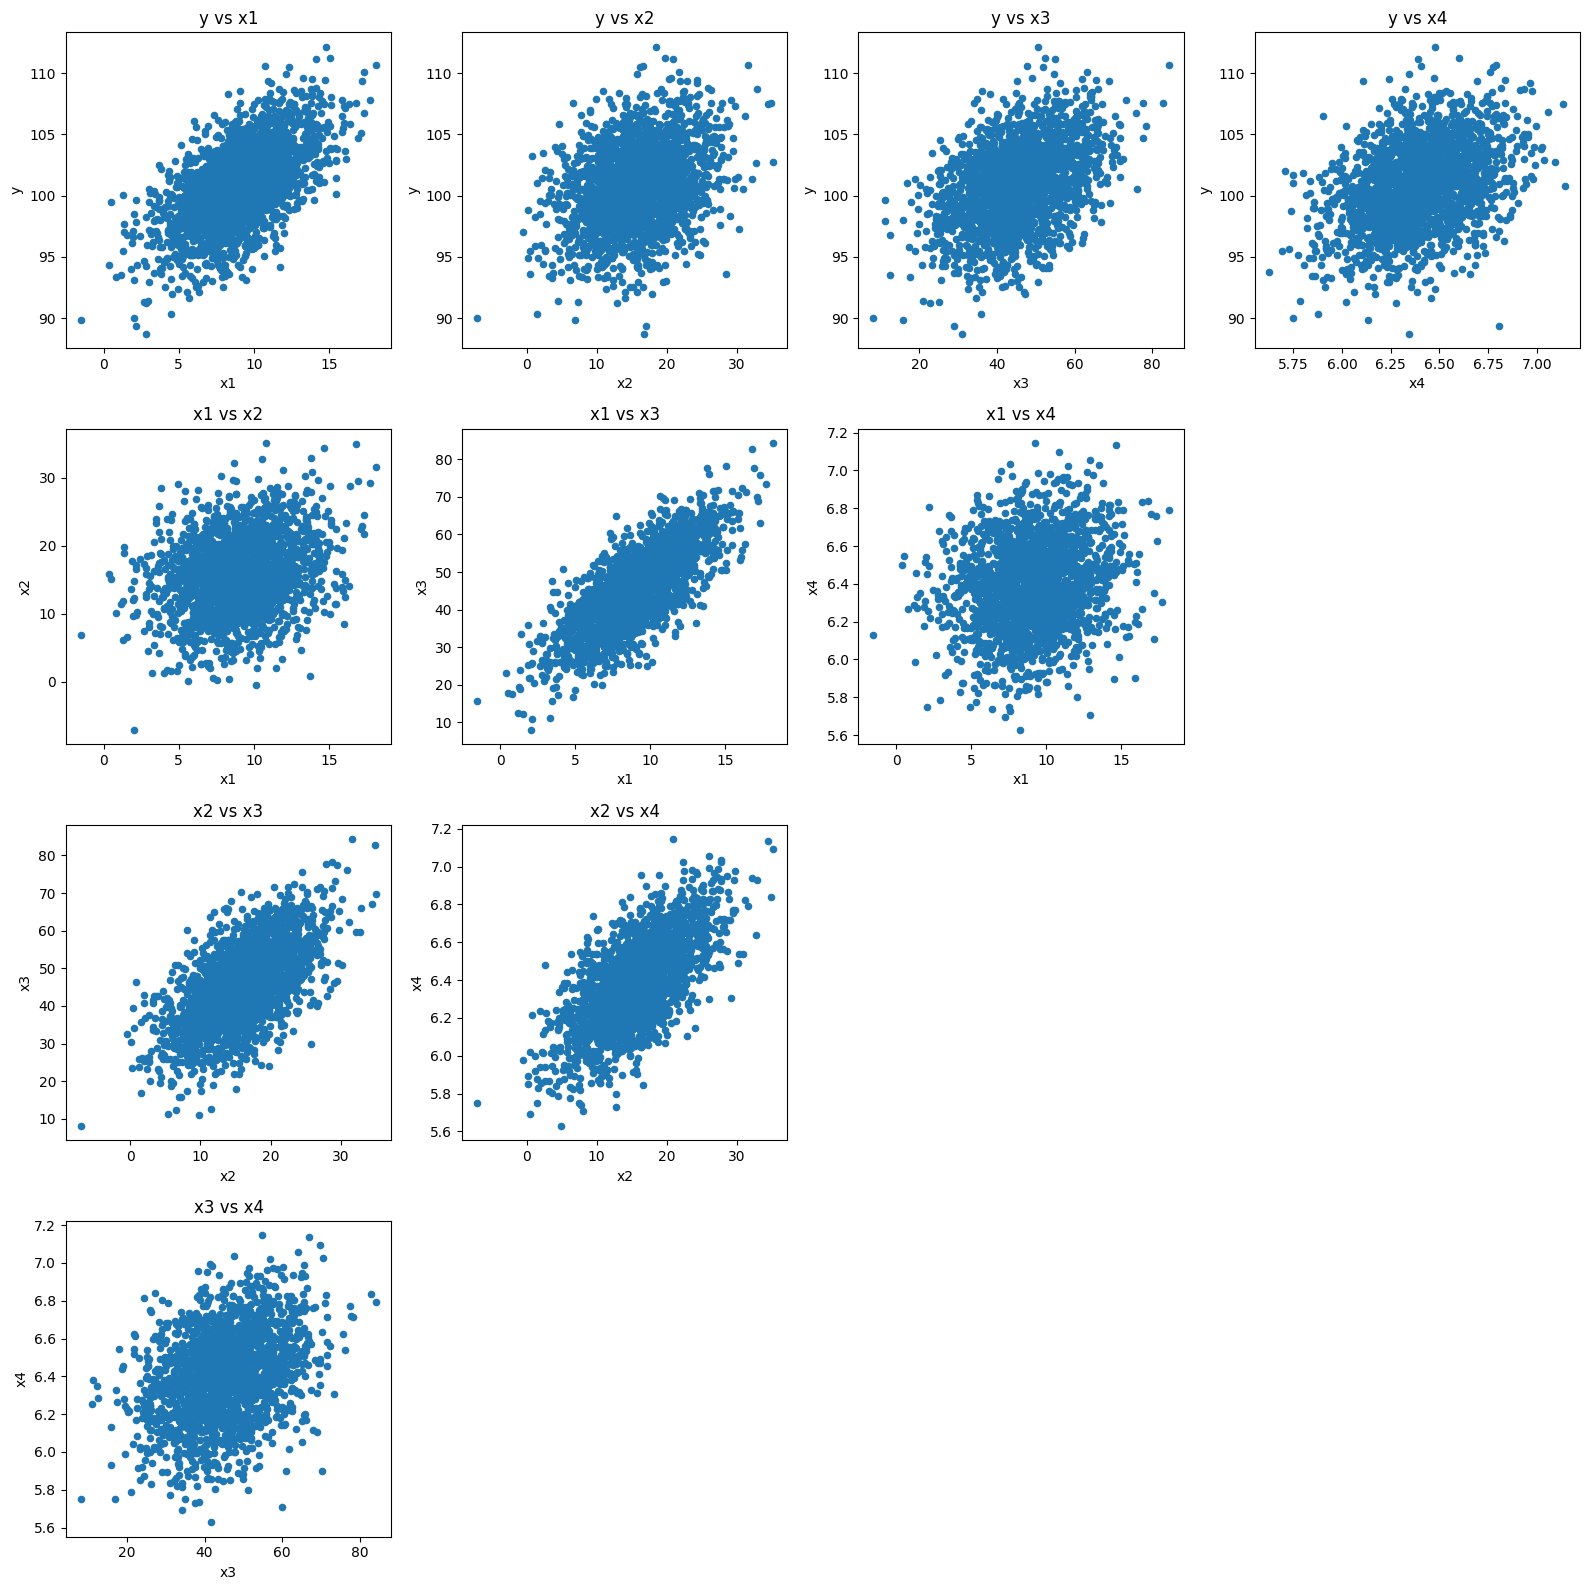

In [13]:
# Plot using the built-in DataFrame plotting method
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# First row: y vs x1, y vs x2, y vs x3, y vs x4
for i, col in enumerate(['x1', 'x2', 'x3', 'x4']):
    df.plot(kind='scatter', x=col, y='y', ax=axes[0, i], title=f'y vs {col}')

# Second row: x1 vs x2, x1 vs x3, x1 vs x4
df.plot(kind='scatter', x='x1', y='x2', ax=axes[1, 0], title='x1 vs x2')
df.plot(kind='scatter', x='x1', y='x3', ax=axes[1, 1], title='x1 vs x3')
df.plot(kind='scatter', x='x1', y='x4', ax=axes[1, 2], title='x1 vs x4')

# Third row: x2 vs x3, x2 vs x4
df.plot(kind='scatter', x='x2', y='x3', ax=axes[2, 0], title='x2 vs x3')
df.plot(kind='scatter', x='x2', y='x4', ax=axes[2, 1], title='x2 vs x4')

# Fourth row: x3 vs x4
df.plot(kind='scatter', x='x3', y='x4', ax=axes[3, 0], title='x3 vs x4')

# Hide the remaining empty subplots in the second row

axes[1, 3].axis('off')
axes[2, 2].axis('off')
axes[2, 3].axis('off')
axes[3, 1].axis('off')
axes[3, 2].axis('off')
axes[3, 3].axis('off')
# Adjust layout
plt.tight_layout()
plt.show()

Second fictitious dataset: dependent variable function generation. Includes different clustering generation.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def simulate_data(n, beta, sigma, sigmas, correlation_structure=None, nonlinear=False):
    # Define correlation matrix based on the specified structure
    p = len(sigmas)  # number of predictors
    if correlation_structure == "0_correlation":
        rho_matrix = np.full((p, p), 0)
        np.fill_diagonal(rho_matrix, 1.0)
    elif correlation_structure == "0.5_correlation":
        rho_matrix = np.full((p, p), 0.5)
        np.fill_diagonal(rho_matrix, 1.0)
    elif correlation_structure == "specific_structure":
        rho_matrix = np.zeros((p, p))
        rho_matrix[0, 1] = rho_matrix[1, 0] = 0.7
        np.fill_diagonal(rho_matrix, 1.0)
    elif correlation_structure == "x4_independent":
        rho_matrix = 0.7 ** np.abs(np.subtract.outer(np.arange(p - 1), np.arange(p - 1)))
        rho_matrix = np.pad(rho_matrix, ((0, 1), (0, 1)), mode='constant')
        np.fill_diagonal(rho_matrix, 1.0)
    elif correlation_structure == "two_strong_groups":
        rho_matrix = np.array([
            [1.0, 0.9, 0.0, 0.0],
            [0.9, 1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.9],
            [0.0, 0.0, 0.9, 1.0]
        ])
    elif correlation_structure == "one_strong_groups":
        rho_matrix = np.array([
            [1.0, 0.8, 0.0, 0.0],
            [0.8, 1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0]
        ])
    else:
        rho_matrix = 0.7 ** np.abs(np.subtract.outer(np.arange(p), np.arange(p)))

    # Calculate covariance matrix using: cov(X_i, X_j) = rho * sigma_i * sigma_j
    cov_matrix = np.outer(sigmas, sigmas) * rho_matrix

    # Generate predictor variables X from a multivariate normal distribution
    X = np.random.multivariate_normal(mean=np.zeros(p), cov=cov_matrix, size=n)

    # Generate noise epsilon
    epsilon = np.random.normal(0, sigma, size=n)

    # Generate response variable y using the specified formula
    if nonlinear:
        y = X[:, 0]**2 + 2 * X[:, 1] + 2 * X[:, 2] + 1.5 * X[:, 3] + epsilon
    else:
        y = X @ beta + epsilon
    
    return X, y

# Simulation settings
n = 2000  # Number of samples
sigmas = np.array([2.5, 2.0, 10.0, 3.0])  # Standard deviations for each predictor

# Define simulations with different beta and sigma values
simulations = [
    {"beta": np.array([3, 2, 1, 0]), "sigma": 3},  # Simulation 1
    {"beta": np.array([3, 2, 1, 0]), "sigma": 3},  # Simulation 2
    {"beta": np.array([3, 0, 0, 2]), "sigma": 3},  # Simulation 3
    {"beta": np.array([0.7, 0.7, 0.7, 0.7]), "sigma": 3},  # Simulation 4
    {"beta": np.array([0, 2, 0, 2]), "sigma": 3},  # Simulation 5
    {"beta": np.array([3, 2, 0, 0]), "sigma": 3},  # Simulation 6
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 3},  # Simulation 7
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 3},  # Simulation 8
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 3},  # Simulation 9
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 3, "nonlinear": True},  # Simulation 10 (non-linear)
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 3, "nonlinear": True}   # Simulation 11 (non-linear)
]

# Run each simulation and store each in a separate DataFrame
simulation_dfs = {}
for i, sim in enumerate(simulations, 1):
    nonlinear = sim.get("nonlinear", False)
    if i == 1:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="0_correlation", nonlinear=nonlinear)
    elif i == 5:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="0.5_correlation", nonlinear=nonlinear)
    elif i == 6:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="specific_structure", nonlinear=nonlinear)
    elif i == 7:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="x4_independent", nonlinear=nonlinear)
    elif i == 8:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="two_strong_groups", nonlinear=nonlinear)
    elif i == 9:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="one_strong_groups", nonlinear=nonlinear)
    else:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, nonlinear=nonlinear)

    # Store each DataFrame in a dictionary with the name "simulationX"
    sim_df = pd.DataFrame(np.column_stack([y, X]), columns=['y', 'x1', 'x2', 'x3', 'x4'])
    simulation_dfs[f'simulation{i}'] = sim_df

# Read simulation9 data for testing purposes
simulation9_data = simulation_dfs['simulation9']
print(simulation9_data)


              y        x1        x2         x3        x4
0     22.315375  1.054574 -0.916715  15.618407 -3.988607
1     12.488045  3.720047  3.062949  -3.426508  1.761444
2     -3.025170  2.058600  0.407182   0.495192 -2.834693
3     -2.076768  0.315339 -1.444005   1.768363 -1.050558
4     18.090363  0.981777  1.216169   7.474645  0.375630
...         ...       ...       ...        ...       ...
1995   7.258999 -4.479738 -4.208494  10.631705  0.572747
1996   4.578857 -1.478294 -1.292311   5.860699 -0.903552
1997  -2.447846 -0.804264 -2.097546   0.111947  1.367932
1998   4.127210  0.920081  0.409053   9.493722 -9.195784
1999   5.521001  0.586219  0.393776   3.214446  0.417329

[2000 rows x 5 columns]


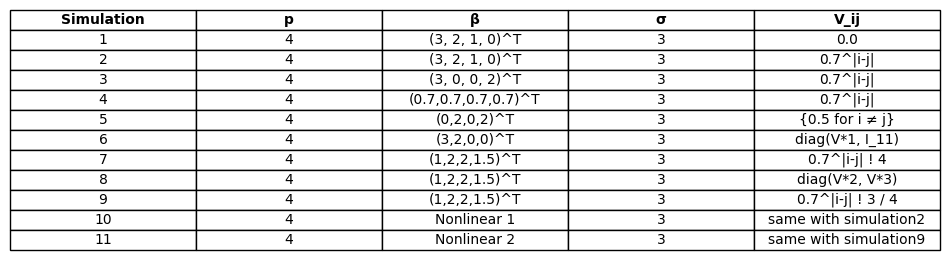

In [16]:
# Create data
data = {
    "Simulation": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "p": [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
    "β": [
        "(3, 2, 1, 0)^T",
        "(3, 2, 1, 0)^T",
        "(3, 0, 0, 2)^T",
        "(0.7,0.7,0.7,0.7)^T",
        "(0,2,0,2)^T",
        "(3,2,0,0)^T",
        "(1,2,2,1.5)^T",
        "(1,2,2,1.5)^T",
        "(1,2,2,1.5)^T",
        "Nonlinear 1",
        "Nonlinear 2",
    ],
    "σ": [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
    "V_ij": [
        "0.0",
        "0.7^|i-j|",
        "0.7^|i-j|",
        "0.7^|i-j|",
        "{0.5 for i ≠ j}",
        "diag(V*1, I_11)",
        "0.7^|i-j| ! 4",
        "diag(V*2, V*3)",
        "0.7^|i-j| ! 3 / 4",
        "same with simulation2",
        "same with simulation9"
    ]
}

# Convert data to DataFrame
df = pd.DataFrame(data)

# Set figure size
fig, ax = plt.subplots(figsize=(10, 3))  # Adjust size as needed

# Hide axis
ax.axis("off")
ax.axis("tight")

# Add table in Matplotlib
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Set header font to bold
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold')

# Auto adjust column width
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)  # Scale table to make it fit nicely

plt.show()


Third fictitious dataset: multiple covariates
    
The nest is a example

In [25]:
def generate_multicollinear_data(n, coef1, coef2, noise_std):
    """
    Generate data for three variables, where x1 and x2 have multicollinearity with x3.

    Parameters:
    n (int): Number of samples
    coef1 (float): Linear coefficient for x1 in constructing x3
    coef2 (float): Linear coefficient for x2 in constructing x3
    noise_std (float): Standard deviation of noise, controlling the degree of multicollinearity in x3

    Returns:
    DataFrame: Dataset containing x1, x2, and x3
    """
    # Generate two independent variables (x1 and x2)
    x1 = np.random.normal(0, 3, n)
    x2 = np.random.normal(0, 5, n)

    # Generate x3 as a linear combination of x1 and x2, plus small noise
    noise = np.random.normal(0, noise_std, n)
    x3 = coef1 * x1 + coef2 * x2 + noise

    # Create DataFrame with generated variables
    df = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
    return df

# Example usage
df3 = generate_multicollinear_data(n=100, coef1=1.5, coef2=-2.0, noise_std=0.1)

# Display correlation matrix and first few rows
print(df3.corr())  # Check for multicollinearity
print(df3.head())  # Display first few rows of the DataFrame

          x1        x2        x3
x1  1.000000  0.024427  0.417423
x2  0.024427  1.000000 -0.898198
x3  0.417423 -0.898198  1.000000
         x1        x2         x3
0  2.904379  4.736214  -5.068792
1  0.126495  6.277016 -12.348151
2 -3.001291 -5.707037   6.989025
3 -2.234585  5.727598 -14.879772
4  2.369036  2.586961  -1.489693


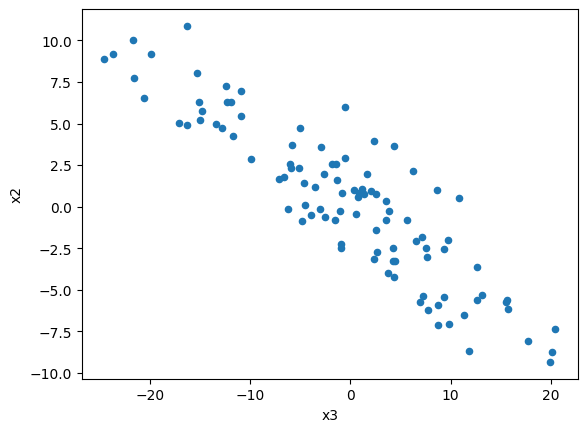

In [26]:
# Display the generated dataset
df3.plot(kind='scatter', x='x3', y='x2')
plt.show()

Now is the true realization

In [27]:
import numpy as np
import pandas as pd

# Global variances for each variable
var_x1, var_x2, var_x3, var_x4 = 4, 9, 100, 9

# Define a function to create each DataFrame with specified correlation structures and generate y as a linear combination
def create_simulation_with_covariance(simulation_num, n=1000):
    # Set up correlation matrices based on required correlation structures
    if simulation_num == 1:
        # x2, x3, x4 are independent
        corr_matrix = np.diag([1, 1, 1])
    elif simulation_num == 2:
        # x2 and x3 weakly correlated, x3 and x4 strongly correlated
        corr_matrix = np.array([
            [1, 0.2, 0.0],
            [0.2, 1, 0.9],
            [0.0, 0.9, 1]
        ])
    elif simulation_num == 3:
        # x4 strongly correlated with both x2 and x3, x2 and x3 weakly correlated
        corr_matrix = np.array([
            [1, 0.3, 0.7],
            [0.3, 1, 0.6],
            [0.7, 0.6, 1]
        ])
    elif simulation_num == 4:
        # x2 and x3 strongly correlated, x4 independent
        corr_matrix = np.array([
            [1, 0.8, 0.0],
            [0.8, 1, 0.0],
            [0.0, 0.0, 1]
        ])
    elif simulation_num == 5:
        # x2, x3, x4 all strongly correlated
        corr_matrix = np.array([
            [1, 0.8, 0.8],
            [0.8, 1, 0.8],
            [0.8, 0.8, 1]
        ])
    elif simulation_num == 6:
        # x2 and x3 weakly correlated
        corr_matrix = np.array([
            [1, 0.2, 0.0],
            [0.2, 1, 0.0],
            [0.0, 0.0, 1]
        ])
    elif simulation_num == 7:
        # x2 and x3 strongly correlated
        corr_matrix = np.array([
            [1, 0.8, 0.0],
            [0.8, 1, 0.0],
            [0.0, 0.0, 1]
        ])
    elif simulation_num == 8:
        # Independent variables for generating x2, x3, x4
        corr_matrix = np.diag([1, 1, 1])
    else:
        raise ValueError("Simulation number must be between 1 and 8")

    # Generate covariance matrix from variances and correlation matrix
    std_devs = np.sqrt([var_x2, var_x3, var_x4])
    cov_matrix = np.outer(std_devs, std_devs) * corr_matrix

    # Generate x2, x3, x4 based on the specified covariance structure
    mean = np.zeros(3)
    x2_x3_x4 = np.random.multivariate_normal(mean, cov_matrix, n)
    x2, x3, x4 = x2_x3_x4[:, 0], x2_x3_x4[:, 1], x2_x3_x4[:, 2]

    # Generate x1 based on different formulas depending on the simulation number
    if simulation_num in [1, 2, 3, 4, 5]:
        x1 = 1.5 * x2 + 2 * x3 + np.random.normal(0, np.sqrt(var_x1), n)
    elif simulation_num == 6:
        x1 = 2 * x2 + 3 * x3 + np.random.normal(0, np.sqrt(var_x1), n)
        x4 = -1 * x2 + 1.5 * x3 + np.random.normal(0, np.sqrt(var_x4), n)
    elif simulation_num == 7:
        x1 = 2 * x2 + 3 * x3 + np.random.normal(0, np.sqrt(var_x1), n)
        x4 = -1 * x2 + 1.5 * x3 + np.random.normal(0, np.sqrt(var_x4), n)
    elif simulation_num == 8:
        x1 = 1.5 * x2 + 2 * x3 - 0.5 * x4 + np.random.normal(0, np.sqrt(var_x1), n)
    
    # Generate y as a linear combination of x1, x2, x3, x4 plus noise
    y = 1.2 * x1 + 0.8 * x2 - 1.5 * x3 + 2.0 * x4 + np.random.normal(0, 3, n)
    
    # Create DataFrame
    df = pd.DataFrame({ 'y': y, 'x1': x1, 'x2': x2, 'x3': x3, 'x4': x4})
    return df

# Generate DataFrames for each simulation
simulations = {}
for i in range(1, 9):
    simulations[f'simulation{i}'] = create_simulation_with_covariance(i)



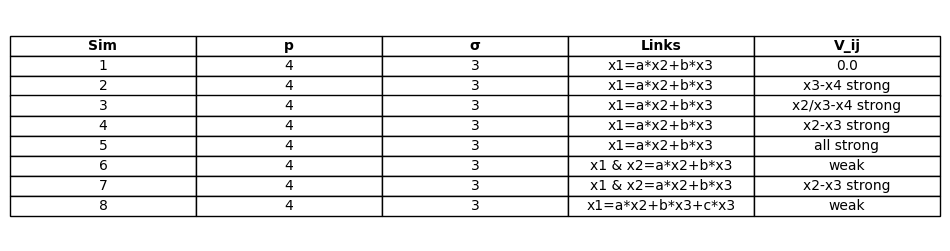

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Create data
data = {
    "Sim": [1, 2, 3, 4, 5, 6, 7, 8],
    "p": [4, 4, 4, 4, 4, 4, 4, 4],
    "σ": [3, 3, 3, 3, 3, 3, 3, 3],
    "Links": [
        "x1=a*x2+b*x3",
        "x1=a*x2+b*x3",
        "x1=a*x2+b*x3",
        "x1=a*x2+b*x3",
        "x1=a*x2+b*x3",
        "x1 & x2=a*x2+b*x3",
        "x1 & x2=a*x2+b*x3",
        "x1=a*x2+b*x3+c*x3",
    ],
    "V_ij": [
        "0.0",
        "x3-x4 strong",
        "x2/x3-x4 strong",
        "x2-x3 strong",
        "all strong",
        "weak",
        "x2-x3 strong",
        "weak",
    ]
}

# Convert data to DataFrame
df = pd.DataFrame(data)

# Set figure size
fig, ax = plt.subplots(figsize=(10, 3))  # Adjust size as needed

# Hide axis
ax.axis("off")
ax.axis("tight")

# Add table in Matplotlib
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Set header font to bold
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold')

# Auto adjust column width
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)  # Scale table to make it fit nicely

plt.show()


The fourth fictitious dataset: different covariances in space
Next picture is just for showing a linear relation on 3D case

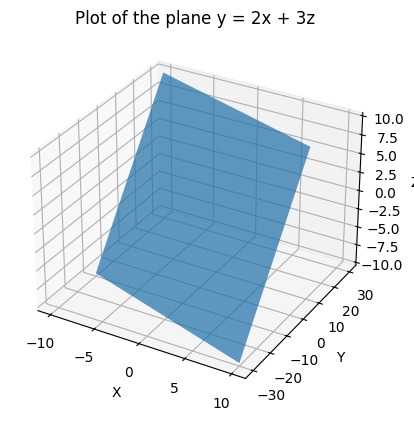

In [29]:
# Generate values for x and z
x = np.linspace(-10, 10, 50)
z = np.linspace(-10, 10, 50)
X, Z = np.meshgrid(x, z)

# Calculate y based on the equation y = 2x + 3z
Y =  -X + 2 * Z

# Plot the 3D plane
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.7, rstride=100, cstride=100)

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Plot of the plane y = 2x + 3z')

plt.show()

Then I will show that the colinearity will make "shrink" on phase picture

          x         z         y
0  2.186499 -0.177021 -2.540540
1  3.649235 -1.753922 -7.157080
2  1.531740  0.492497 -0.546747
3  1.497188  0.424122 -0.648944
4  1.455080  0.612473 -0.230134
          x         z         y
x  1.000000 -0.878183 -0.941627
z -0.878183  1.000000  0.987953
y -0.941627  0.987953  1.000000


Text(0.5, 0.92, '3D Scatter Plot of y = x + 3z')

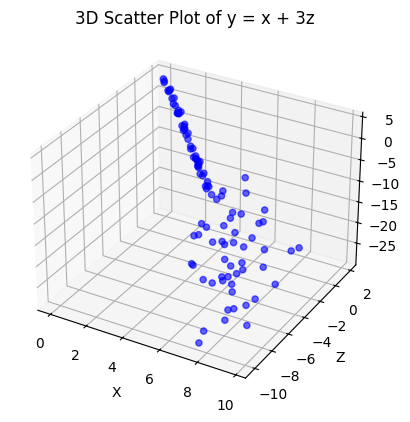

In [45]:
def generate_data(n=100, noise_std_strong=0.1, noise_std_weak=2.0):
    """
    Generate data for y = x - 3z, where x and z have strong collinearity for x in (0, 5)
    and weaker collinearity for x in (5, 10).

    Parameters:
    n (int): Total number of samples
    noise_std_strong (float): Standard deviation of noise in (0, 5) range for strong collinearity
    noise_std_weak (float): Standard deviation of noise in (5, 10) range for weaker collinearity

    Returns:
    DataFrame: Dataset containing x, z, and y
    """
    # Split samples equally between the two ranges
    n_half = n // 2
    
    # Generate x and z for the (0, 5) range with strong collinearity
    x1 = np.random.uniform(0, 5, n_half)
    z1 = 2 - x1 + np.random.normal(0, noise_std_strong, n_half)  # Strong collinearity: x + z ~ 2

    # Generate x and z for the (5, 10) range with weaker collinearity
    x2 = np.random.uniform(5, 10, n_half)
    z2 = 2 - x2 + np.random.normal(0, noise_std_weak, n_half)  # Weaker collinearity: x + z ≠ 2

    # Combine x and z values
    x = np.concatenate([x1, x2])
    z = np.concatenate([z1, z2])

    # Calculate y based on the equation y = x - 3z
    y = -x+2 * z

    # Create DataFrame
    df = pd.DataFrame({'x': x, 'z': z, 'y': y})
    
    return df

# Generate the data
df = generate_data(n=100, noise_std_strong=0.1, noise_std_weak=2.0)

# Display the first few rows and correlation matrix to check collinearity
print(df.head())
print(df.corr())
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x'], df['z'], df['y'], c='b', alpha=0.6)

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')
ax.set_title('3D Scatter Plot of y = x + 3z')

I needed to create a way to automatically classify the data into clusters 
with different linear relationships based on the characteristics of this shrinking distribution on a multidimensional space

In [46]:
# Sort df by ‘x’ column in ascending order
df = df.sort_values(by='x').reset_index(drop=True)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

In [47]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

def calculate_pca_features(data: pd.DataFrame, k_neighbors: int = 5):
    """
    Calculate the principal component eigenvalues and eigenvectors for each point.

    Parameters:
    data (pd.DataFrame): Input four-dimensional data, containing four columns, each row represents the coordinates of a point
    k_neighbors (int): Number of neighbors for each point, default is 5

    Returns:
    pd.DataFrame: DataFrame containing the eigenvalues and eigenvectors for each point
    """
    # Use K-nearest neighbors search to find neighbors
    nbrs = NearestNeighbors(n_neighbors=k_neighbors+1).fit(data.values)
    _, indices = nbrs.kneighbors(data.values)

    # Store the principal component eigenvalues and eigenvectors for each point
    pca_features = []

    for i in range(len(data)):
        # Select the neighbors of the i-th point (excluding itself)
        neighbors = data.values[indices[i][1:]]

        # Perform PCA to analyze the distribution of neighborhood points
        pca = PCA(n_components=3)
        pca.fit(neighbors)

        # Get eigenvalues and eigenvectors
        eigenvalues = pca.explained_variance_
        eigenvectors = pca.components_

        # Determine dimension type
        if eigenvalues[1] < 0.1 * eigenvalues[0]:
            dimension_type = 'Linear'  # Collinear
        elif eigenvalues[2] < 0.1 * eigenvalues[1]:
            dimension_type = 'Planar'  # Coplanar
        else:
            dimension_type = 'Three-dimensional'  # 3D distribution

        # Store the results
        pca_features.append((eigenvalues, eigenvectors, dimension_type))

    # Create a DataFrame with the results
    result_df = pd.DataFrame({
        'Point Index': np.arange(len(data)),
        'Eigenvalues': [pca_features[i][0] for i in range(len(data))],
        'Eigenvectors': [pca_features[i][1] for i in range(len(data))],
        'Dimension Type': [pca_features[i][2] for i in range(len(data))]
    })

    return result_df


In [48]:
pca_result = calculate_pca_features(df, k_neighbors=5)
print(pca_result['Eigenvalues'])

0     [0.41580052857156363, 0.004065010550044711, 1....
1     [0.5510488795461919, 0.0041764496454316635, 5....
2     [0.6175378602470138, 0.0034919673180101272, 2....
3     [0.6023486887725279, 0.0037455979024404186, 1....
4     [0.4033858036297006, 0.005057432733065924, 1.3...
                            ...                        
95    [2.0532141146687004, 0.10733013862166554, 3.43...
96    [2.6606947776681706, 0.03681809344507101, 3.80...
97    [1.884027016634396, 1.0541349245885456, 1.0682...
98    [2.811962361950453, 0.39408381860949376, 5.940...
99    [1.2281112586683787, 0.2746422939463568, 3.163...
Name: Eigenvalues, Length: 100, dtype: object


In [49]:
import matplotlib.pyplot as plt

def plot_3d_scatter_with_dimension(df: pd.DataFrame):
    """
    Plot a 3D scatter plot, coloring data points based on different dimension types.

    Parameters:
    df (pd.DataFrame): Dataset containing three-dimensional coordinates ('x', 'y', 'z') and 'Dimension Type'
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Set colors for each dimension type
    colors = {'Linear': 'blue', 'Planar': 'green', 'Three-dimensional': 'red'}
    
    # Plot data points for each dimension type
    for dimension_type, color in colors.items():
        subset = df[df['Dimension Type'] == dimension_type]
        ax.scatter(subset['x'], subset['y'], subset['z'], c=color, label=dimension_type, alpha=0.6)

    # Chart settings
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.title("3D Scatter Plot by Dimension Type")
    plt.show()


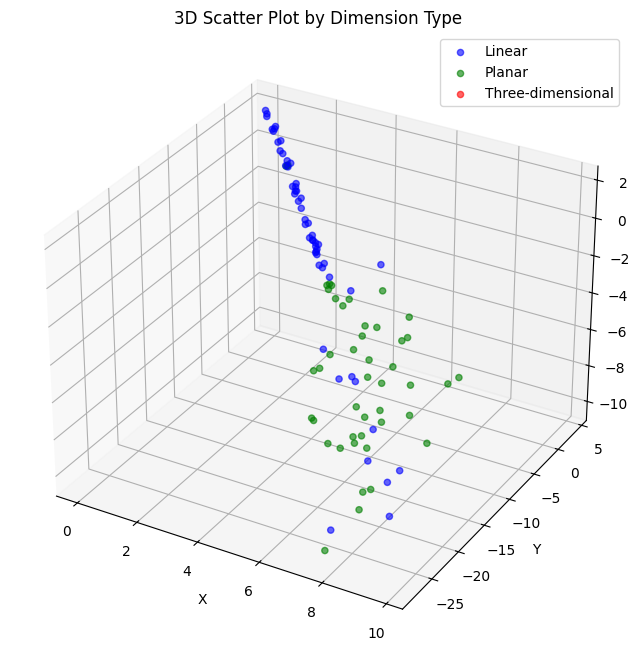

In [50]:
merged_df = df.copy()
merged_df['Dimension Type'] = pca_result['Dimension Type']
# Scatterplotting
plot_3d_scatter_with_dimension(merged_df)

In [61]:

def plot_first_principal_components(pca_result: pd.DataFrame):
    """
    Visualize the first principal component eigenvectors of the first two points in the PCA result.

    Parameters:
    pca_result (pd.DataFrame): PCA result DataFrame containing the 'Eigenvectors' column
    """
    # Extract the first principal component eigenvectors of the first two points
    vector1 = pca_result['Eigenvectors'].iloc[0][0]  # First principal component of the first point
    vector2 = pca_result['Eigenvectors'].iloc[1][0]  # First principal component of the second point
    vector3 = pca_result['Eigenvectors'].iloc[1][1]  # Second principal component of the second point

    # Set up the plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot eigenvectors
    origin = np.array([[0, 0, 0], [0, 0, 0],[0, 0, 0]])  # Origin coordinates
    vectors = np.array([vector1, vector2,vector3])
    
    for i in range(3):
        ax.quiver(*origin[i], *vectors[i], length=1.0, normalize=True, color=['blue', 'green','red'][i], 
                  label=f'Point {i+1}  Principal Component')

    # Set legend and axis labels
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.title("First Principal Components of the First Two Points")
    plt.show()


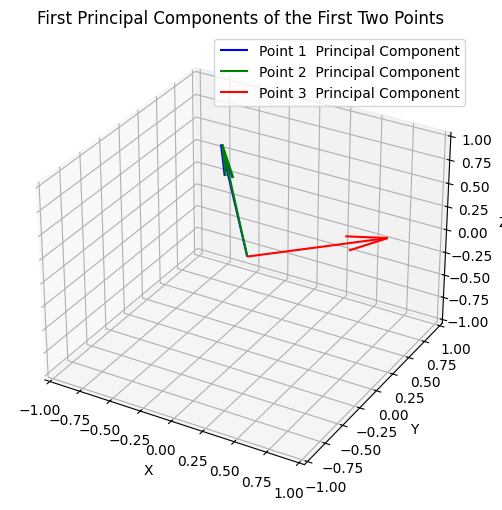

In [62]:
# Plot the first principal component eigenvector for the first two points
plot_first_principal_components(pca_result)

Expanded to a five-dimensional state, y,x1,x2,x3,x4

In [140]:
# Parameters
n = 200
mean_x1 = 0  # Overall mean for x1
sigma_x1 = 1.5  # Overall standard deviation for x1
initial_sigmas = np.array([8.5, 2.0, 1.0, 30.0])  # Initial std devs for x1, x2, x3, x4
beta = np.array([3, 2, 1.5, 0])  # Regression coefficients
sigma_y = 3  # Standard deviation for y's noise

# Fixed means for x2, x3, and x4
means_x_rest = np.array([1.0, -1.0, 0.5])

# Generate and sort x1, then split it into four segments
x1 = np.random.normal(mean_x1, sigma_x1, n)
x1_sorted_indices = np.argsort(x1)
x1_sorted = x1[x1_sorted_indices]

# Split x1 into four segments
segment_indices = np.array_split(x1_sorted_indices, 4)

# Define covariance structure for each segment
segments_params = [
    {"rho_matrix": np.array([
        [1.0, 0.8, 0.4, 0.2],
        [0.8, 1.0, 0.3, 0.1],
        [0.4, 0.3, 1.0, 0.5],
        [0.2, 0.1, 0.5, 1.0]
    ])},
    {"rho_matrix": np.array([
        [1.0, 0.2, 0.1, 0.0],
        [0.2, 1.0, 0.8, 0.4],
        [0.1, 0.8, 1.0, 0.6],
        [0.0, 0.4, 0.6, 1.0]
    ])},
    {"rho_matrix": np.array([
        [1.0, 0.5, 0.3, 0.1],
        [0.5, 1.0, 0.5, 0.4],
        [0.3, 0.5, 1.0, 0.7],
        [0.1, 0.4, 0.7, 1.0]
    ])},
    {"rho_matrix": np.array([
        [1.0, 0.8, 0.2, 0.1],
        [0.8, 1.0, 0.4, 0.3],
        [0.2, 0.4, 1.0, 0.8],
        [0.1, 0.3, 0.8, 1.0]
    ])}
]

# Initialize X and fill x1
X = np.zeros((n, 4))
X[:, 0] = x1  # Assign x1 values

for i, indices in enumerate(segment_indices):
    # Get x1 values for the current segment
    x1_segment = X[indices, 0]
    n_segment = len(x1_segment)
    
    # Calculate mean and standard deviation of x1 in this segment
    mean_x1_segment = np.mean(x1_segment)
    std_x1_segment = np.std(x1_segment)
    
    # Update sigmas with the segment-specific standard deviation for x1
    segment_sigmas = initial_sigmas.copy()
    segment_sigmas[0] = std_x1_segment
    
    # Generate the covariance matrix for this segment
    rho_matrix = segments_params[i]["rho_matrix"]
    cov_matrix = np.outer(segment_sigmas, segment_sigmas) * rho_matrix
    
    # Extract components for conditional distribution
    cov_11 = cov_matrix[0, 0]  # Variance of x1 in this segment
    cov_12 = cov_matrix[0, 1:]  # Covariances between x1 and [x2, x3, x4]
    cov_22 = cov_matrix[1:, 1:]  # Covariance matrix for [x2, x3, x4]

    # Compute conditional mean and covariance
    mean_cond = means_x_rest + (cov_12 / cov_11) * (x1_segment - mean_x1_segment)[:, None]
    cov_cond = cov_22 - np.outer(cov_12, cov_12) / cov_11

    # Generate x2, x3, x4 based on conditional distribution
    x_rest = np.random.multivariate_normal(mean=np.zeros(3), cov=cov_cond, size=n_segment) + mean_cond
    X[indices, 1:] = x_rest  # Assign x2, x3, x4 to the segment

# Generate y
epsilon = np.random.normal(0, sigma_y, size=n)
y = X @ beta + epsilon

# Combine into DataFrame
df_final = pd.DataFrame(np.column_stack([y, X]), columns=['y', 'x1', 'x2', 'x3', 'x4'])
df_final['x1_quantile'] = np.repeat(range(4), [len(indices) for indices in segment_indices])

# Display result
df_final.head()

,y,x1,x2,x3,x4,x1_quantile
0,-0.479724,0.255783,0.308128,-2.028450,-50.433307,0
1,6.962696,1.932672,0.298258,-1.282141,-18.706972,0
2,20.125379,4.191199,6.667891,0.099204,16.676893,0
3,-11.879520,0.112006,-3.295900,-2.213061,-21.280003,0
4,-6.892143,-0.657497,-1.345699,-1.852802,-50.318922,0


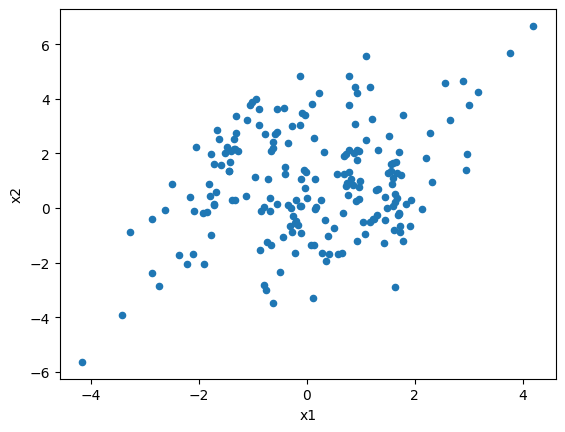

In [141]:
# Display the generated dataset
df_final.plot(kind='scatter', x='x1', y='x2')
plt.show()

Fifth fictitious dataset: different covariances on scales
    
Consider only: large scale covariance, small scale non-covariance case
Visualisation example: three-variable case. y,x1,x2

In [68]:


# Specify parameters
x1_means = np.array([20.0, 50.0, 80.0])   # Mean of x1 in three segments
variance_x1 = 1.5                        # Variance of x1
variance_x2 = 2.0                        # Variance of x2
pearson_r = 0.8                          # Specified Pearson correlation coefficient
num_samples_per_segment = 100            # Number of samples per segment

# Parameters for generating the linear relationship
a, b = 3, 2
epsilon = np.random.normal(0, 0.25, size=3)

# Initialize result arrays
x1_segments = []
x2_segments = []
y_segments = []

# Generate x1 and x2 data for each segment
for i in range(3):
    # Construct mean vector
    mean_vector = [mean_x1[i], (mean_x1[i] * pearson_r + epsilon[i])]
    
    # Construct covariance matrix
    covariance_matrix = [[variance_x1, 0],
                         [0, variance_x2]]
    
    # Generate samples from a multivariate normal distribution
    samples = np.random.multivariate_normal(mean_vector, covariance_matrix, num_samples_per_segment)
    
    # Split x1 and x2 data
    x1_segment = samples[:, 0]
    x2_segment = samples[:, 1]

    # Generate y through a linear relationship
    y_segment = a * x1_segment + b * x2_segment + 2

    # Append results for each segment to lists
    x1_segments.append(x1_segment)
    x2_segments.append(x2_segment)
    y_segments.append(y_segment)

# Concatenate the results into complete sequences
x1 = np.concatenate(x1_segments)
x2 = np.concatenate(x2_segments)
y = np.concatenate(y_segments)


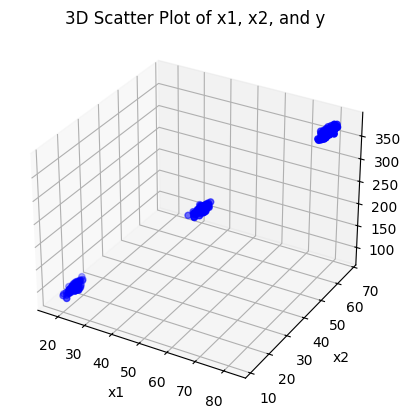

,x1,x2,y
0,22.614011,14.200217,98.242467
1,18.882968,16.210679,91.070261
2,19.900632,15.054389,91.810674
3,19.163046,14.286753,88.062644
4,21.659385,14.258184,95.494522


In [69]:

# Put the results into a DataFrame
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

# 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x1'], df['x2'], df['y'], c='b', marker='o')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title("3D Scatter Plot of x1, x2, and y")
plt.show()

# Display DataFrame
df.head()


In [71]:
correlations = []
for i, mean in enumerate(x1_means):
    # Define the start and end index for each segment
    start_index = i * num_samples_per_segment
    end_index = start_index + num_samples_per_segment
    
    # Select the segment data for x1 and x2
    segment_x1 = df['x1'].iloc[start_index:end_index]
    segment_x2 = df['x2'].iloc[start_index:end_index]
    
    # Calculate correlation between x1 and x2 for the segment
    correlation = segment_x1.corr(segment_x2)
    correlations.append((f"Segment {i+1} (Mean of x1: {mean})", correlation))

# Display results
for segment, corr in correlations:
    print(f"{segment}: Correlation between x1 and x2 = {corr:.4f}")

Segment 1 (Mean of x1: 20.0): Correlation between x1 and x2 = -0.0506
Segment 2 (Mean of x1: 50.0): Correlation between x1 and x2 = 0.0682
Segment 3 (Mean of x1: 80.0): Correlation between x1 and x2 = 0.0452


QUESTION: Does the form of the nonlinearity between x not matter, only the nonlinearity between y and x needs to be considered?

The actual implementation under the above setup

In [72]:


# Specify parameters
mean_x1 = np.array([20.0, 25.0, 30.0])   # Mean of x1 in three segments
variance_x1 = 1.5                        # Variance of x1
variance_x2 = 2.0                        # Variance of x2
variance_x3 = 1.0                        # Variance of x3
variance_x4 = 0.5                        # Variance of x4
pearson_r = 0.8                          # Specified Pearson correlation coefficient
num_samples_per_segment = 100            # Number of samples per segment

# Parameters for generating the linear relationship
a, b, c, d = 3, 2, 1.5, 0.5              # Coefficients for each variable in y
epsilon = np.random.normal(0, 2.25, size=3)  # Random noise

# Initialize result arrays
x1_segments = []
x2_segments = []
x3_segments = []
x4_segments = []
y_segments = []

# Generate x1, x2, x3, x4 data for each segment
for i in range(3):
    # Construct mean vector
    mean_vector = [mean_x1[i], 
                   mean_x1[i] * pearson_r + epsilon[i],
                   mean_x1[i] * pearson_r * 0.8 + epsilon[i],  # Adjust mean with pearson_r
                   mean_x1[i] * pearson_r * 0.6 + epsilon[i]]
    
    # Construct covariance matrix; x1, x2, x3, x4 are independent within each segment
    covariance_matrix = np.diag([variance_x1, variance_x2, variance_x3, variance_x4])
    
    # Generate samples from a multivariate normal distribution
    samples = np.random.multivariate_normal(mean_vector, covariance_matrix, num_samples_per_segment)
    
    # Split x1, x2, x3, x4 data
    x1_segment = samples[:, 0]
    x2_segment = samples[:, 1]
    x3_segment = samples[:, 2]
    x4_segment = samples[:, 3]
    
    # Generate y through a linear relationship and add noise
    noise = np.random.normal(0, 0.5, num_samples_per_segment)  # Noise for y
    y_segment = a * x1_segment + b * x2_segment + c * x3_segment + d * x4_segment + noise

    # Append results for each segment to lists
    x1_segments.append(x1_segment)
    x2_segments.append(x2_segment)
    x3_segments.append(x3_segment)
    x4_segments.append(x4_segment)
    y_segments.append(y_segment)

# Concatenate the results into complete sequences
x1 = np.concatenate(x1_segments)
x2 = np.concatenate(x2_segments)
x3 = np.concatenate(x3_segments)
x4 = np.concatenate(x4_segments)
y = np.concatenate(y_segments)


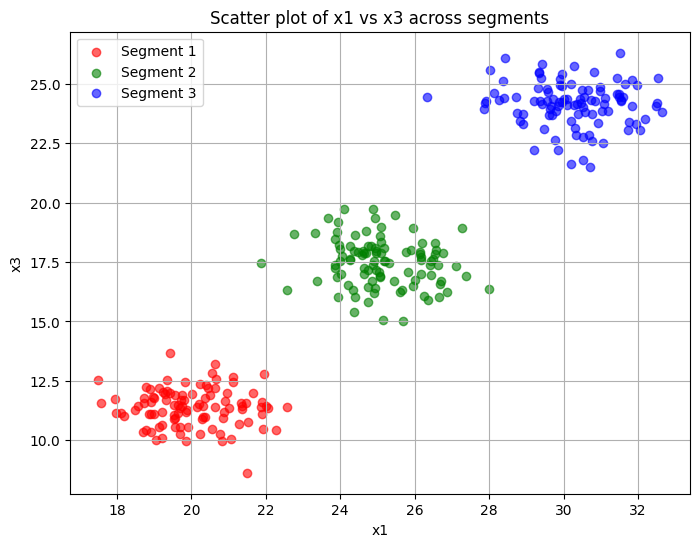

In [74]:
import matplotlib.pyplot as plt

# Define color list to distinguish each segment
colors = ['red', 'green', 'blue']

# Set up the plot
plt.figure(figsize=(8, 6))

# Plot x1 and x3 for each segment
for i, color in enumerate(colors):
    start_idx = i * num_samples_per_segment
    end_idx = start_idx + num_samples_per_segment
    plt.scatter(x1[start_idx:end_idx], x3[start_idx:end_idx], color=color, label=f'Segment {i+1}', alpha=0.6)

# Add legend and labels
plt.xlabel('x1')
plt.ylabel('x3')
plt.title('Scatter plot of x1 vs x3 across segments')
plt.legend()
plt.grid(True)
plt.show()
